[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Dataset Shape: (3448, 2)
                                                Text  Sentiment  \
0  According to Gran , the company has no plans t...          1   
1  With the new production plant the company woul...          2   
2  For the last quarter of 2010 , Componenta 's n...          2   
3  In the third quarter of 2010 , net sales incre...          2   
4  Operating profit rose to EUR 13.1 mn from EUR ...          2   

                                        Text_Cleaned  
0  according to gran   the company has no plans t...  
1  with the new production plant the company woul...  
2  for the last quarter of 2010   componenta  s n...  
3  in the third quarter of 2010   net sales incre...  
4  operating profit rose to eur 13 1 mn from eur ...  

Training Samples: 2758
Testing Samples: 690

Running VADER Sentiment Analysis...

Training Accuracy: 55.62%
Testing Accuracy: 57.10%


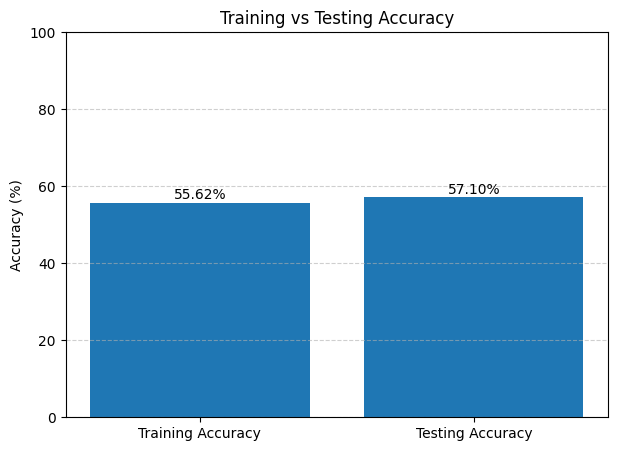

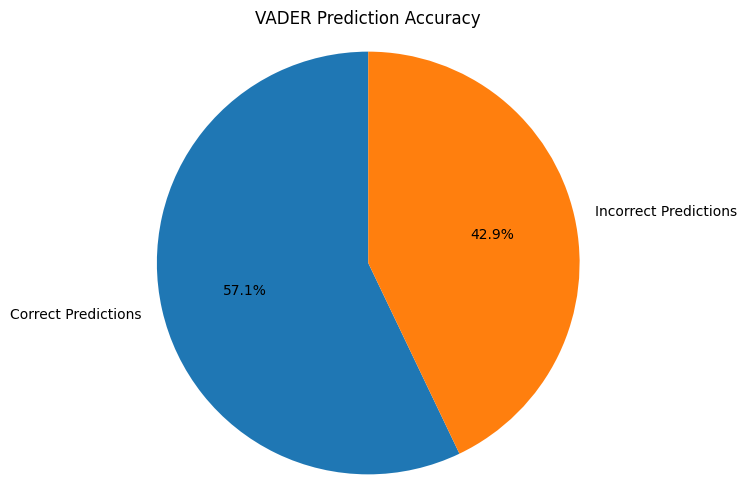

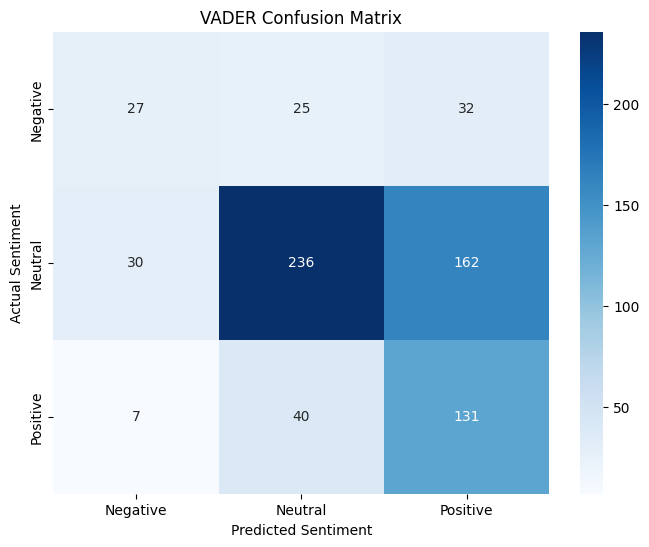


Classification Report:

              precision    recall  f1-score   support

    Negative       0.42      0.32      0.36        84
     Neutral       0.78      0.55      0.65       428
    Positive       0.40      0.74      0.52       178

    accuracy                           0.57       690
   macro avg       0.54      0.54      0.51       690
weighted avg       0.64      0.57      0.58       690



In [1]:
# ============================================================
# VADER SENTIMENT ANALYSIS - FINANCIAL PHRASEBANK
# ============================================================

# !pip install pandas numpy nltk matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# ============================================================
# DOWNLOAD VADER LEXICON
# ============================================================

nltk.download('vader_lexicon')

from nltk.sentiment.vader import SentimentIntensityAnalyzer

# ============================================================
# 1. LOAD FINANCIAL PHRASEBANK DATASET
# ============================================================

texts = []
labels = []

with open(
    'Sentences_75Agree.txt',
    'r',
    encoding='latin1'
) as file:

    lines = file.readlines()

    for line in lines:

        line = line.strip()

        if len(line) == 0:
            continue

        text, sentiment = line.rsplit('@', 1)

        texts.append(text.strip())
        labels.append(sentiment.strip())

# Create dataframe
data = pd.DataFrame({
    'Text': texts,
    'Sentiment': labels
})

# Remove duplicates
data.drop_duplicates(
    subset=['Text'],
    inplace=True
)

print("Dataset Shape:", data.shape)

# ============================================================
# 2. LABEL ENCODING
# ============================================================

label_mapping = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

data['Sentiment'] = data['Sentiment'].map(
    label_mapping
)

# ============================================================
# 3. PREPROCESSING
# ============================================================

def preprocess_tweets(data):

    data['Text_Cleaned'] = data['Text'].astype(str).str.lower()

    # Remove URLs
    data['Text_Cleaned'] = data['Text_Cleaned'].replace(
        r'http\\S+|www\\S+|https\\S+',
        '',
        regex=True
    )

    # Remove mentions
    data['Text_Cleaned'] = data['Text_Cleaned'].replace(
        r'@[A-Za-z0-9_]+',
        '',
        regex=True
    )

    # Remove hashtags
    data['Text_Cleaned'] = data['Text_Cleaned'].replace(
        r'#[A-Za-z0-9_]+',
        '',
        regex=True
    )

    # Remove special characters
    data['Text_Cleaned'] = data['Text_Cleaned'].replace(
        r'[^a-zA-Z0-9\\s]',
        ' ',
        regex=True
    )

    # Remove extra spaces
    data['Text_Cleaned'] = data['Text_Cleaned'].replace(
        r'\\s+',
        ' ',
        regex=True
    )

    data['Text_Cleaned'] = data['Text_Cleaned'].str.strip()

    return data

data = preprocess_tweets(data)

# Remove short texts
data = data[
    data['Text_Cleaned'].str.len() > 5
]

print(data.head())

# ============================================================
# 4. TRAIN TEST SPLIT
# ============================================================

X = data['Text_Cleaned'].values
y = data['Sentiment'].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))

# ============================================================
# 5. INITIALIZE VADER
# ============================================================

print("\nRunning VADER Sentiment Analysis...")

sid = SentimentIntensityAnalyzer()

# ============================================================
# 6. TRAINING PREDICTIONS
# ============================================================

train_scores = []

for text in X_train:

    score = sid.polarity_scores(
        str(text)
    )['compound']

    train_scores.append(score)

# ============================================================
# VADER LABEL MAPPING
# ============================================================

def vader_label(score):

    if score >= 0.05:
        return 2      # Positive

    elif score <= -0.05:
        return 0      # Negative

    else:
        return 1      # Neutral

train_preds = [
    vader_label(score)
    for score in train_scores
]

# ============================================================
# 7. TESTING PREDICTIONS
# ============================================================

test_scores = []

for text in X_test:

    score = sid.polarity_scores(
        str(text)
    )['compound']

    test_scores.append(score)

test_preds = [
    vader_label(score)
    for score in test_scores
]

# ============================================================
# 8. ACCURACY CALCULATION
# ============================================================

train_accuracy = accuracy_score(
    y_train,
    train_preds
) * 100

test_accuracy = accuracy_score(
    y_test,
    test_preds
) * 100

print(
    f"\nTraining Accuracy: {train_accuracy:.2f}%"
)

print(
    f"Testing Accuracy: {test_accuracy:.2f}%"
)

# ============================================================
# 9. TRAINING VS TESTING ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ['Training Accuracy', 'Testing Accuracy'],
    [train_accuracy, test_accuracy]
)

plt.title(
    'Training vs Testing Accuracy'
)

plt.ylabel('Accuracy (%)')

plt.ylim(0, 100)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.2f}%',
        ha='center'
    )

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.6
)

plt.show()

# ============================================================
# 10. PIE CHART
# ============================================================

correct = np.sum(
    np.array(test_preds) == y_test
)

incorrect = len(y_test) - correct

labels = [
    'Correct Predictions',
    'Incorrect Predictions'
]

sizes = [
    correct,
    incorrect
]

plt.figure(figsize=(6, 6))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('VADER Prediction Accuracy')

plt.axis('equal')

plt.show()

# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    test_preds
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'Negative',
        'Neutral',
        'Positive'
    ],
    yticklabels=[
        'Negative',
        'Neutral',
        'Positive'
    ]
)

plt.title(
    "VADER Confusion Matrix"
)

plt.xlabel(
    'Predicted Sentiment'
)

plt.ylabel(
    'Actual Sentiment'
)

plt.show()

# ============================================================
# 12. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        test_preds,
        target_names=[
            'Negative',
            'Neutral',
            'Positive'
        ]
    )
)